In [1]:
!hostname

cn021.delta.ncsa.illinois.edu


In [2]:
import multivelo as mv

/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-p

In [3]:
import jax
print(jax.devices())  # should show [CpuDevice(id=0)]
print(mv.__version__)

[CpuDevice(id=0)]
0.1.3


In [4]:
import os
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt
import anndata as ad

In [5]:
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'figure.frameon': False,
    'font.size': 14,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})
import matplotlib.pyplot as plt

scv.settings.verbosity = 3
scv.settings.presenter_view = True
# Skip scv.set_figure_params('scvelo') — causes matplotlib_inline version conflict
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

In [6]:
x_dr_file = '/work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/data/coord_rna.tsv.gz'
stream_obs_file = '/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/adata_stream_obs.tsv.gz'
rna_adata_file = '/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/bcell_rna.h5ad'
atac_adata_file = '/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/bcell_atac.h5ad'

#### Checking loom files

In [7]:
loom_folder = '/work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related'

In [8]:
import loompy

ds = loompy.connect(
    os.path.join(loom_folder, "velocyto_day0_2/multiome_1st_donor_UPMC_day0_2.loom"),
    validate=False
)

# 1. Check cell barcodes
print("First 5 barcodes:", ds.ca["CellID"][:5])

# 2. Check matrix layers and shape
print("Layers:", list(ds.layers.keys()))
print("Shape (genes x cells):", ds.shape)

# 3. Check global/row/col attributes
print("Global attrs:", dict(ds.attrs))
print("Row attrs:", list(ds.ra.keys()))
print("Col attrs:", list(ds.ca.keys()))

ds.close()

First 5 barcodes: ['multiome_1st_donor_UPMC_day0_2:AAACGCGCAAGCTTATx'
 'multiome_1st_donor_UPMC_day0_2:AAACCGAAGTCATGCGx'
 'multiome_1st_donor_UPMC_day0_2:AAACATGCAGCTCAACx'
 'multiome_1st_donor_UPMC_day0_2:AAACGCGCACGCAACTx'
 'multiome_1st_donor_UPMC_day0_2:AAACCGAAGGGATGACx']
Layers: ['', 'ambiguous', 'spliced', 'unspliced']
Shape (genes x cells): (36601, 15285)
Global attrs: {'last_modified': '20240731T232513.499888Z'}
Row attrs: ['Accession', 'Chromosome', 'End', 'Gene', 'Start', 'Strand']
Col attrs: ['CellID', 'Clusters']


# Adapting code for multivelo 

In [9]:
BASE = "/work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2"

# Velocyto loom files (RNA spliced/unspliced)
LOOM_DIR = os.path.join(BASE, "velocity_related")
LOOM_FILES = {
    "day0_2": os.path.join(LOOM_DIR, "velocyto_day0_2/multiome_1st_donor_UPMC_day0_2.loom"),
    "day3_4": os.path.join(LOOM_DIR, "velocyto_day3_4/multiome_1st_donor_UPMC_day3_4.loom"), 
    "day5_6": os.path.join(LOOM_DIR, "velocyto_day5_6/multiome_1st_donor_UPMC_day5_6.loom"), 
}

# RNA h5ad has X_MultiVI in .obsm, cell type labels, UMAP, etc.
RNA_H5AD = "/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/bcell_rna.h5ad"
ATAC_H5AD = "/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/bcell_atac.h5ad"

# CellRanger ARC output directories (one per sample)
# Needed for: peak_annotation.tsv (atac_peak_annotation.tsv) + feature_linkage.bedpe
CELLRANGER_ARC_OUTS = {
    "day0_2": os.path.join(BASE, "/work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day0_2/outs"),
    "day3_4": os.path.join(BASE, "/work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day3_4/outs"),
    "day5_6": os.path.join(BASE, "/work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day5_6/outs"),
}

# Output directory
OUT_DIR = os.path.join(BASE, "multivelo_results")
os.makedirs(OUT_DIR, exist_ok=True)

In [10]:
from scipy.sparse import csr_matrix
looms = {}
for tp, path in LOOM_FILES.items():
    print(f"\n--- Loading {tp} ---")
    ds = loompy.connect(path, validate=False)
    adata = ad.AnnData(
        X=csr_matrix(ds.layers['spliced'][:, :].T),
        obs=pd.DataFrame(index=ds.ca['CellID']),
        var=pd.DataFrame(index=ds.ra['Gene']),
    )
    adata.layers['spliced'] = adata.X.copy()
    adata.layers['unspliced'] = csr_matrix(ds.layers['unspliced'][:, :].T)
    adata.layers['ambiguous'] = csr_matrix(ds.layers['ambiguous'][:, :].T)
    ds.close()
    adata.var_names_make_unique()
    looms[tp] = adata

# ══════════════ HARMONIZE LOOM BARCODES ══════════════
batch_map = {"day0_2": "1", "day3_4": "2", "day5_6": "3"}

for tp, adata in looms.items():
    suffix = batch_map[tp]
    # 'multiome_...:AAACGCGCAAGCTTATx' → 'AAACGCGCAAGCTTAT-1'
    adata.obs_names = [bc.split(":")[-1].rstrip("x") + "-" + suffix for bc in adata.obs_names]
    print(f"Loom {tp}: {adata.obs_names[:2].tolist()}")

adata_rna = ad.concat(list(looms.values()), join='outer')
adata_rna.var_names_make_unique()


--- Loading day0_2 ---

--- Loading day3_4 ---

--- Loading day5_6 ---
Loom day0_2: ['AAACGCGCAAGCTTAT-1', 'AAACCGAAGTCATGCG-1']
Loom day3_4: ['AAACCAACACCTGCCT-2', 'AAACATGCATAATCCG-2']
Loom day5_6: ['AAAGCCGCACCTCACC-3', 'AAACCGCGTGAGACTC-3']


In [11]:
# Print raw barcodes from each source
for tp, adata in looms.items():
    print(f"\nLoom {tp}: {adata.obs_names[:3].tolist()}")
 
# Load exported RNA h5ad (contains X_MultiVI, cell types, UMAP)
adata_ref = sc.read_h5ad(RNA_H5AD)


Loom day0_2: ['AAACGCGCAAGCTTAT-1', 'AAACCGAAGTCATGCG-1', 'AAACATGCAGCTCAAC-1']

Loom day3_4: ['AAACCAACACCTGCCT-2', 'AAACATGCATAATCCG-2', 'AAACCGCGTTTCCTCC-2']

Loom day5_6: ['AAAGCCGCACCTCACC-3', 'AAACCGCGTGAGACTC-3', 'AAACGTACATGAGTTT-3']


In [12]:
adata_ref.obs['sub_cell_type'].value_counts()

ActB-1       5283
ActB-2       4647
ActB-4       4440
GC-1         4365
ActB-3       3984
GC-2         2515
PB-2         2345
earlyPB       657
earlyActB     258
Name: sub_cell_type, dtype: int64

In [13]:
# %%
atac_samples = {}
for tp, outs_dir in CELLRANGER_ARC_OUTS.items():
    print(f"\n--- Processing ATAC for {tp} ---")
    
    mtx_dir = os.path.join(outs_dir, "filtered_feature_bc_matrix")
    peak_annot = os.path.join(outs_dir, "atac_peak_annotation.tsv")
    feat_link = os.path.join(outs_dir, "feature_linkage.bedpe")
    
    # Check files exist
    for f in [mtx_dir, peak_annot, feat_link]:
        exists = os.path.exists(f)
        print(f"  {'✓' if exists else '✗'} {f}")
    
    # Load full feature matrix (RNA + ATAC), then subset to peaks
    adata_full = sc.read_10x_mtx(mtx_dir, var_names='gene_symbols', cache=False, gex_only=False)
    adata_peaks = adata_full[:, adata_full.var['feature_types'] == "Peaks"].copy()
    print(f"  Raw peaks: {adata_peaks.shape}")
    
    # Aggregate peaks to gene level
    import scipy.sparse
    scipy.sparse.csc_matrix.A = property(lambda self: self.toarray())
    scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())
    
    adata_peaks = mv.aggregate_peaks_10x(adata_peaks, peak_annot, feat_link)
    print(f"  Gene-aggregated ATAC: {adata_peaks.shape}")
    
    adata_peaks.obs['timepoint'] = tp
    atac_samples[tp] = adata_peaks


--- Processing ATAC for day0_2 ---
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day0_2/outs/filtered_feature_bc_matrix
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day0_2/outs/atac_peak_annotation.tsv
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day0_2/outs/feature_linkage.bedpe
  Raw peaks: (15285, 155769)


  0%|          | 0/20445 [00:00<?, ?it/s]

  Gene-aggregated ATAC: (15285, 20445)

--- Processing ATAC for day3_4 ---
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day3_4/outs/filtered_feature_bc_matrix
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day3_4/outs/atac_peak_annotation.tsv
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day3_4/outs/feature_linkage.bedpe
  Raw peaks: (11127, 169355)


  0%|          | 0/20610 [00:00<?, ?it/s]

  Gene-aggregated ATAC: (11127, 20610)

--- Processing ATAC for day5_6 ---
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day5_6/outs/filtered_feature_bc_matrix
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day5_6/outs/atac_peak_annotation.tsv
  ✓ /work/hdd/bgdb/asachan/datasets/B_cell_dictys_actb1_added_v2/velocity_related/velocyto_day5_6/outs/feature_linkage.bedpe
  Raw peaks: (9894, 168188)


  0%|          | 0/20598 [00:00<?, ?it/s]

  Gene-aggregated ATAC: (9894, 20598)


In [ ]:
# save adata_peaks in cache
import pickle
with open('/projects/bgdb/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/trajectory/.cache/adata_peaks_cache.pkl', 'wb') as f:
    pickle.dump(adata_peaks, f)


In [15]:
# ══════════════ HARMONIZE ATAC BARCODES ══════════════
# CellRanger ARC barcodes are all '-1', need to remap per sample
for tp, adata in atac_samples.items():
    suffix = batch_map[tp]
    # 'AAACAGCCAAACCTTG-1' → 'AAACAGCCAAACCTTG-1' (day0_2) or '-2' (day3_4) or '-3' (day5_6)
    adata.obs_names = [bc.rsplit("-", 1)[0] + "-" + suffix for bc in adata.obs_names]
    print(f"ATAC {tp}: {adata.obs_names[:2].tolist()}")

adata_atac = ad.concat(list(atac_samples.values()), join='outer')
adata_atac.var_names_make_unique()

# ══════════════ CHECK OVERLAP ══════════════
shared_rna_atac = pd.Index(np.intersect1d(adata_rna.obs_names, adata_atac.obs_names))
shared_all = pd.Index(np.intersect1d(shared_rna_atac, adata_ref.obs_names))
print(f"\nRNA: {adata_rna.n_obs}, ATAC: {adata_atac.n_obs}, Ref: {adata_ref.n_obs}")
print(f"RNA ∩ ATAC: {len(shared_rna_atac)}")
print(f"RNA ∩ ATAC ∩ Ref: {len(shared_all)}")

ATAC day0_2: ['AAACAGCCAAACCTTG-1', 'AAACAGCCAAAGCTAA-1']
ATAC day3_4: ['AAACAGCCAATTATGC-2', 'AAACATGCAATAACGA-2']
ATAC day5_6: ['AAACAGCCAAGCCACT-3', 'AAACAGCCATTCAGCA-3']

RNA: 36306, ATAC: 36306, Ref: 28494
RNA ∩ ATAC: 36306
RNA ∩ ATAC ∩ Ref: 28494


In [16]:
# Subset to shared cells
adata_rna = adata_rna[shared_all].copy()
adata_atac = adata_atac[shared_all].copy()
 
# Find shared genes
shared_genes = pd.Index(np.intersect1d(adata_rna.var_names, adata_atac.var_names))
print(f"Shared genes: {len(shared_genes)}")
 
adata_rna = adata_rna[:, shared_genes].copy()
adata_atac = adata_atac[:, shared_genes].copy()
 
print(f"RNA final:  {adata_rna.shape}")
print(f"ATAC final: {adata_atac.shape}")

Shared genes: 21902
RNA final:  (28494, 21902)
ATAC final: (28494, 21902)


In [17]:
# Transfer annotations from exported RNA h5ad
shared_idx = adata_rna.obs_names
 
# Cell type labels
if 'sub_cell_type' in adata_ref.obs.columns:
    adata_rna.obs['celltype'] = adata_ref.obs.loc[shared_idx, 'sub_cell_type'].values
elif 'cell_type_major' in adata_ref.obs.columns:
    adata_rna.obs['temporal_cluster'] = adata_ref.obs.loc[shared_idx, 'cell_type_major'].values
 
# UMAP
if 'X_umap' in adata_ref.obsm:
    adata_rna.obsm['X_umap'] = adata_ref[shared_idx].obsm['X_umap'].copy()
    adata_atac.obsm['X_umap'] = adata_ref[shared_idx].obsm['X_umap'].copy()
 
# X_MultiVI (attached to RNA h5ad during export)
if 'X_MultiVI' in adata_ref.obsm:
    adata_rna.obsm['X_MultiVI'] = adata_ref[shared_idx].obsm['X_MultiVI'].copy()
    adata_atac.obsm['X_MultiVI'] = adata_ref[shared_idx].obsm['X_MultiVI'].copy()
    print("✓ Transferred X_MultiVI from exported RNA h5ad")
else:
    print("⚠️  X_MultiVI not found in RNA h5ad obsm. Available keys:", list(adata_ref.obsm.keys()))
 
print(f"Transferred: celltype, X_umap, X_MultiVI")
print(f"Cell types: {adata_rna.obs['celltype'].value_counts().to_dict()}")
 

✓ Transferred X_MultiVI from exported RNA h5ad
Transferred: celltype, X_umap, X_MultiVI
Cell types: {'ActB-1': 5283, 'ActB-2': 4647, 'ActB-4': 4440, 'GC-1': 4365, 'ActB-3': 3984, 'GC-2': 2515, 'PB-2': 2345, 'earlyPB': 657, 'earlyActB': 258}


In [18]:
# Examine spliced/unspliced proportions
spliced_sum = np.array(adata_rna.layers['spliced'].sum(1)).flatten()
unspliced_sum = np.array(adata_rna.layers['unspliced'].sum(1)).flatten()
unspliced_frac = unspliced_sum / (spliced_sum + unspliced_sum + 1e-10)
print(f"Unspliced fraction: mean={unspliced_frac.mean():.3f}, median={np.median(unspliced_frac):.3f}")

Unspliced fraction: mean=0.383, median=0.377


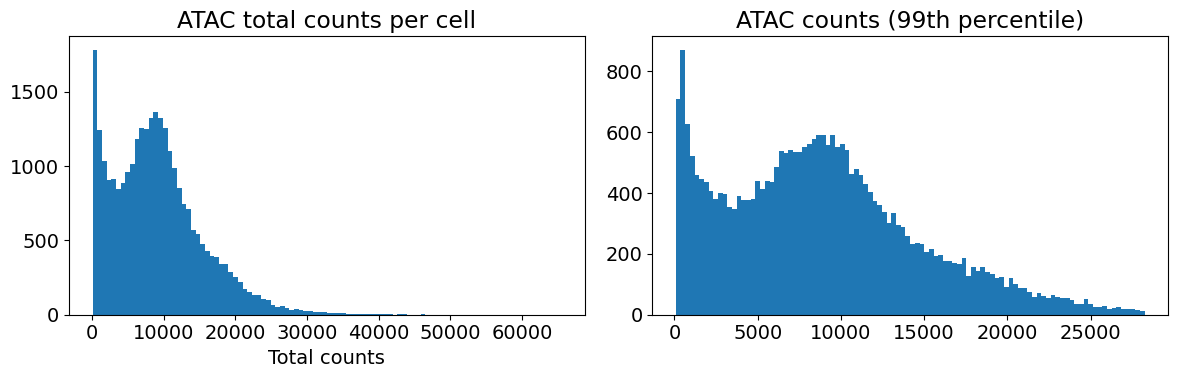

In [19]:
# ATAC QC — examine total count distribution
atac_counts = np.array(adata_atac.X.sum(1)).flatten()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(atac_counts, bins=100)
axes[0].set_title("ATAC total counts per cell")
axes[0].set_xlabel("Total counts")
axes[1].hist(atac_counts[atac_counts < np.percentile(atac_counts, 99)], bins=100)
axes[1].set_title("ATAC counts (99th percentile)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "atac_qc_hist.png"), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Build Neighbor Graph from X_MultiVI which captures both RNA and ATAC in a joint latent space.
 
# %%
# Compute neighbors from X_MultiVI for RNA (used by scVelo moments)
sc.pp.neighbors(adata_rna, use_rep='X_MultiVI', n_neighbors=30)
print("RNA neighbors computed from X_MultiVI")
 
# %%
# Copy neighbor graph to ATAC for chromatin smoothing
adata_atac.obsp['connectivities'] = adata_rna.obsp['connectivities'].copy()
adata_atac.obsp['distances'] = adata_rna.obsp['distances'].copy()
adata_atac.uns['neighbors'] = adata_rna.uns['neighbors'].copy()
print("Copied X_MultiVI neighbor graph to ATAC object")

RNA neighbors computed from X_MultiVI
Copied X_MultiVI neighbor graph to ATAC object


In [21]:
# %%
# RNA: scVelo preprocessing (normalize, log-transform, compute moments)
scv.pp.filter_and_normalize(adata_rna, min_shared_counts=10, n_top_genes=2000)
scv.pp.moments(adata_rna, n_pcs=None, n_neighbors=None)
# n_pcs=None, n_neighbors=None → uses existing neighbor graph from X_MultiVI
 
print(f"RNA after filter: {adata_rna.shape}")
print(f"Layers: {list(adata_rna.layers.keys())}")
 
# %%
# ATAC: TF-IDF normalization then smooth with neighbor graph
# Subset ATAC to shared genes after RNA filtering
shared_genes_post = pd.Index(np.intersect1d(adata_rna.var_names, adata_atac.var_names))
adata_atac = adata_atac[:, shared_genes_post].copy()
 
mv.tfidf_norm(adata_atac)
print(f"ATAC after TF-IDF: {adata_atac.shape}")

Filtered out 12082 genes that are detected 10 counts (shared).
Normalized count data: X, spliced, unspliced.


/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.or

Extracted 2000 highly variable genes.
Logarithmized X.
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
RNA after filter: (28494, 2000)
Layers: ['spliced', 'unspliced', 'ambiguous', 'Ms', 'Mu']
ATAC after TF-IDF: (28494, 2000)


In [24]:
# Smooth chromatin accessibility using the X_MultiVI neighbor graph
mv.knn_smooth_chrom(adata_atac, conn=adata_rna.obsp['connectivities'].copy())
print("ATAC smoothed with X_MultiVI neighbors")
print(f"ATAC layers: {list(adata_atac.layers.keys())}")  # should have 'Mc'

ATAC smoothed with X_MultiVI neighbors
ATAC layers: ['Mc']


In [25]:
# %%
assert np.all(adata_rna.obs_names == adata_atac.obs_names), "Cell order mismatch!"
assert np.all(adata_rna.var_names == adata_atac.var_names), "Gene order mismatch!"
print(f"✓ Aligned: {adata_rna.n_obs} cells × {adata_rna.n_vars} genes")
print(f"  RNA layers: {list(adata_rna.layers.keys())}")
print(f"  ATAC layers: {list(adata_atac.layers.keys())}")

✓ Aligned: 28494 cells × 2000 genes
  RNA layers: ['spliced', 'unspliced', 'ambiguous', 'Ms', 'Mu']
  ATAC layers: ['Mc']


In [26]:
# save adata_rna and adata_atac in cache
import pickle
with open('/projects/bgdb/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/trajectory/.cache/adata_rna_cache.pkl', 'wb') as f:
    pickle.dump(adata_rna, f)
with open('/projects/bgdb/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/trajectory/.cache/adata_atac_cache.pkl', 'wb') as f:
    pickle.dump(adata_atac, f)

# Run multivelo

In [29]:
sc.pl.umap(adata_rna, color='celltype', show=False)  # this auto-creates uns['celltype_colors']
plt.close()

In [30]:
adata_result = mv.recover_dynamics_chrom(
    adata_rna,
    adata_atac,
    max_iter=5,
    init_mode="invert",
    parallel=True,
    n_jobs=16,
    save_plot=False,
    rna_only=False,
    fit=True,
    n_anchors=500,
    extra_color_key='celltype',
)
 
# Save checkpoint
adata_result.write(os.path.join(OUT_DIR, "multivelo_result.h5ad"))
print(f"Saved: {os.path.join(OUT_DIR, 'multivelo_result.h5ad')}")

/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/ipywidgets/widgets/widget.py:503: DeprecationWarning: The `ipykernel.comm.Comm` class has been deprecated. Please use the `comm` module instead.For creating comms, use the function `from comm import create_comm`.
  self.comm = Comm(**args)


  0%|          | 0/2000 [00:00<?, ?it/s]

/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-p

KeyboardInterrupt: 